In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/final_dataset.csv", low_memory=False)

movies = df.drop_duplicates(subset=["movieId"]).copy()
movies = movies.dropna(subset=["release_year"])
movies["release_year"] = movies["release_year"].astype(int)

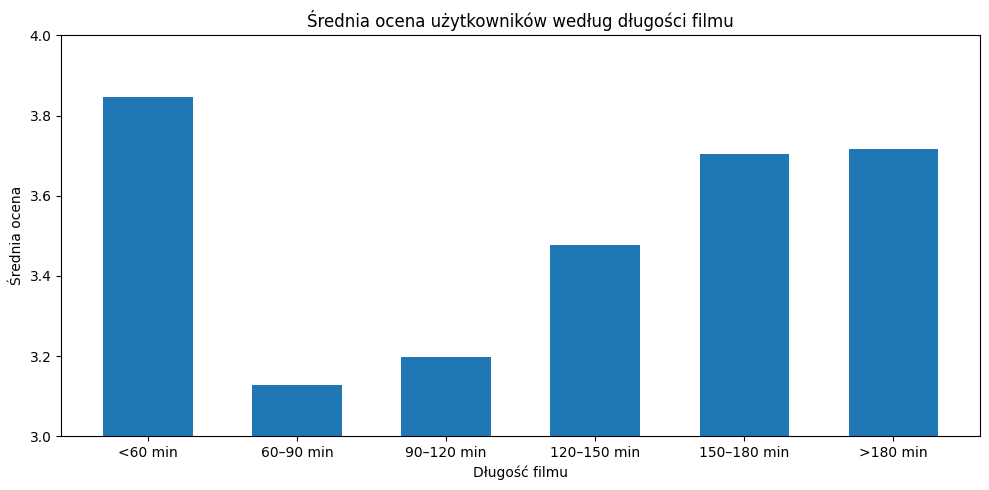

In [11]:
bins = [0, 60, 90, 120, 150, 180, 300]
labels = ["<60 min", "60–90 min", "90–120 min", "120–150 min", "150–180 min", ">180 min"]
movies["runtime_bin"] = pd.cut(movies["runtime"], bins=bins, labels=labels)
stats = (movies.dropna(subset=["runtime", "avg_user_rating_x"])
         .groupby("runtime_bin", observed=True)["avg_user_rating_x"]
         .agg(mean="mean", median="median", count="count")
         .reset_index())

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(stats["runtime_bin"], stats["mean"], width=0.6)
ax.set_title("Średnia ocena użytkowników według długości filmu")
ax.set_xlabel("Długość filmu")
ax.set_ylabel("Średnia ocena")
ax.set_ylim(3, 4)
plt.tight_layout()
plt.show()